La ecuación de difusión:
$$\frac{\partial T}{\partial t} = \alpha\left(\frac{\partial^2 T}{\partial x^2} + \frac{\partial^2 T}{\partial y^2}\right)$$

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

In [3]:
#parámetros físicos
alfa = 1.27
L = 50
T_ext = 0
T_int = 670

N = 100
dx = L / ( N - 1 )
dt = 0.01
rtar = alfa * dt / dx ** 2

Nt = 900
tol = 1e-4

T = np.zeros((N,N))
T_save = {0 : T.copy()}

In [76]:
#Condiciones iniciales:
#T[0,:] = T_ext
#T[-1,:] = T_ext
#T[:, 0] = T_ext
#T[:, -1] = T_ext
#T[45:55, 45:55] = T_int
#for n in range(1, Nt):
 #   T[0,:] = T_ext
  #  T[-1,:] = T_ext
   # T[:, 0] = T_ext
    #T[:, -1] = T_ext
    #T[45:55, 45:55] = T_int
    #T_new = T.copy()
    ##T_new[1:-1, 1:-1] = T[1:-1, 1:-1] + rtar * (T[2:, 1:-1] + T[:-2, 1:-1] + T[1:-1, 2:] + T[1:-1, :-2] - 4 * T[1:-1, 1:-1])
    #T = T_new


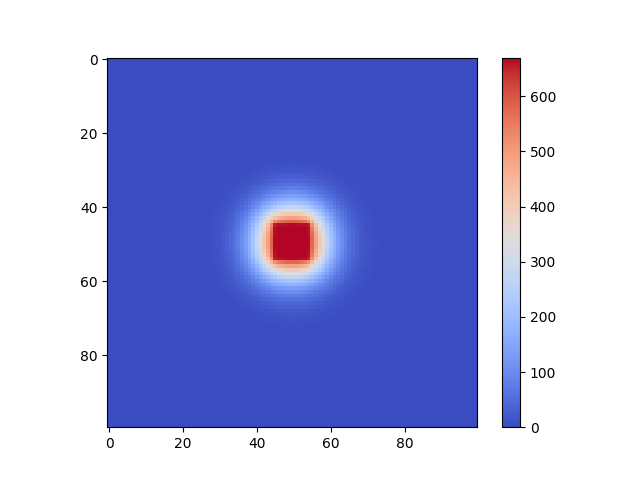

In [6]:
fig, ax = plt.subplots()

%matplotlib widget
#im = ax.imshow(
 #   T.T,
  #  origin = 'lower',
   # extent = [0, L, 0, L],
    #cmap = 'viridis',
    #vmin = -0.5,
    #vmax = 1.0
    #)
im = ax.imshow(T, animated = True, cmap = 'coolwarm')
plt.colorbar(im, ax = ax)
def animate(frame):
    global T
    T[0,:] = T_ext
    T[-1,:] = T_ext
    T[:, 0] = T_ext
    T[:, -1] = T_ext
    T[45:55, 45:55] = T_int
    T_new = T.copy()
    for i in range (1, N-1):
        for j in range(1, N - 1):
            T_new[i, j] = T[i, j] + rtar * (T[i + 1, j] + T[i - 1, j] + T[i, j + 1] + T[i, j - 1] - 4 * T[i, j])
            T = T_new
    im.set_array(T)

    return [im]

anim = FuncAnimation(fig, animate, frames = Nt, interval = 30)
plt.show()